In [1]:
import cv2
import numpy as np

def phash(image_path, hash_size=8, highfreq_factor=4):
    """
    Compute perceptual hash (pHash) for an image.
    
    :param image_path: path to image
    :param hash_size: final hash will be hash_size x hash_size (default 8 → 64-bit hash)
    :param highfreq_factor: resize factor (default 4 → 32x32 before DCT)
    :return: binary hash as numpy array (flattened)
    """
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    # Resize to (hash_size * highfreq_factor)
    size = hash_size * highfreq_factor
    img = cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)

    # Convert to float32 for DCT
    img = np.float32(img)

    # Apply DCT
    dct = cv2.dct(img)

    # Take top-left (low-frequency) block
    dct_lowfreq = dct[:hash_size, :hash_size]

    # Compute median
    median = np.median(dct_lowfreq)

    # Build hash: 1 if above median, else 0
    hash_bits = dct_lowfreq > median

    return hash_bits.flatten()

def hamming_distance(hash1, hash2):
    """Compute Hamming distance between two hashes."""
    return np.count_nonzero(hash1 != hash2)

/mnt/4C74F47B74F468DA/Pictures/IMG_0032-2017-12-27 175948.JPG


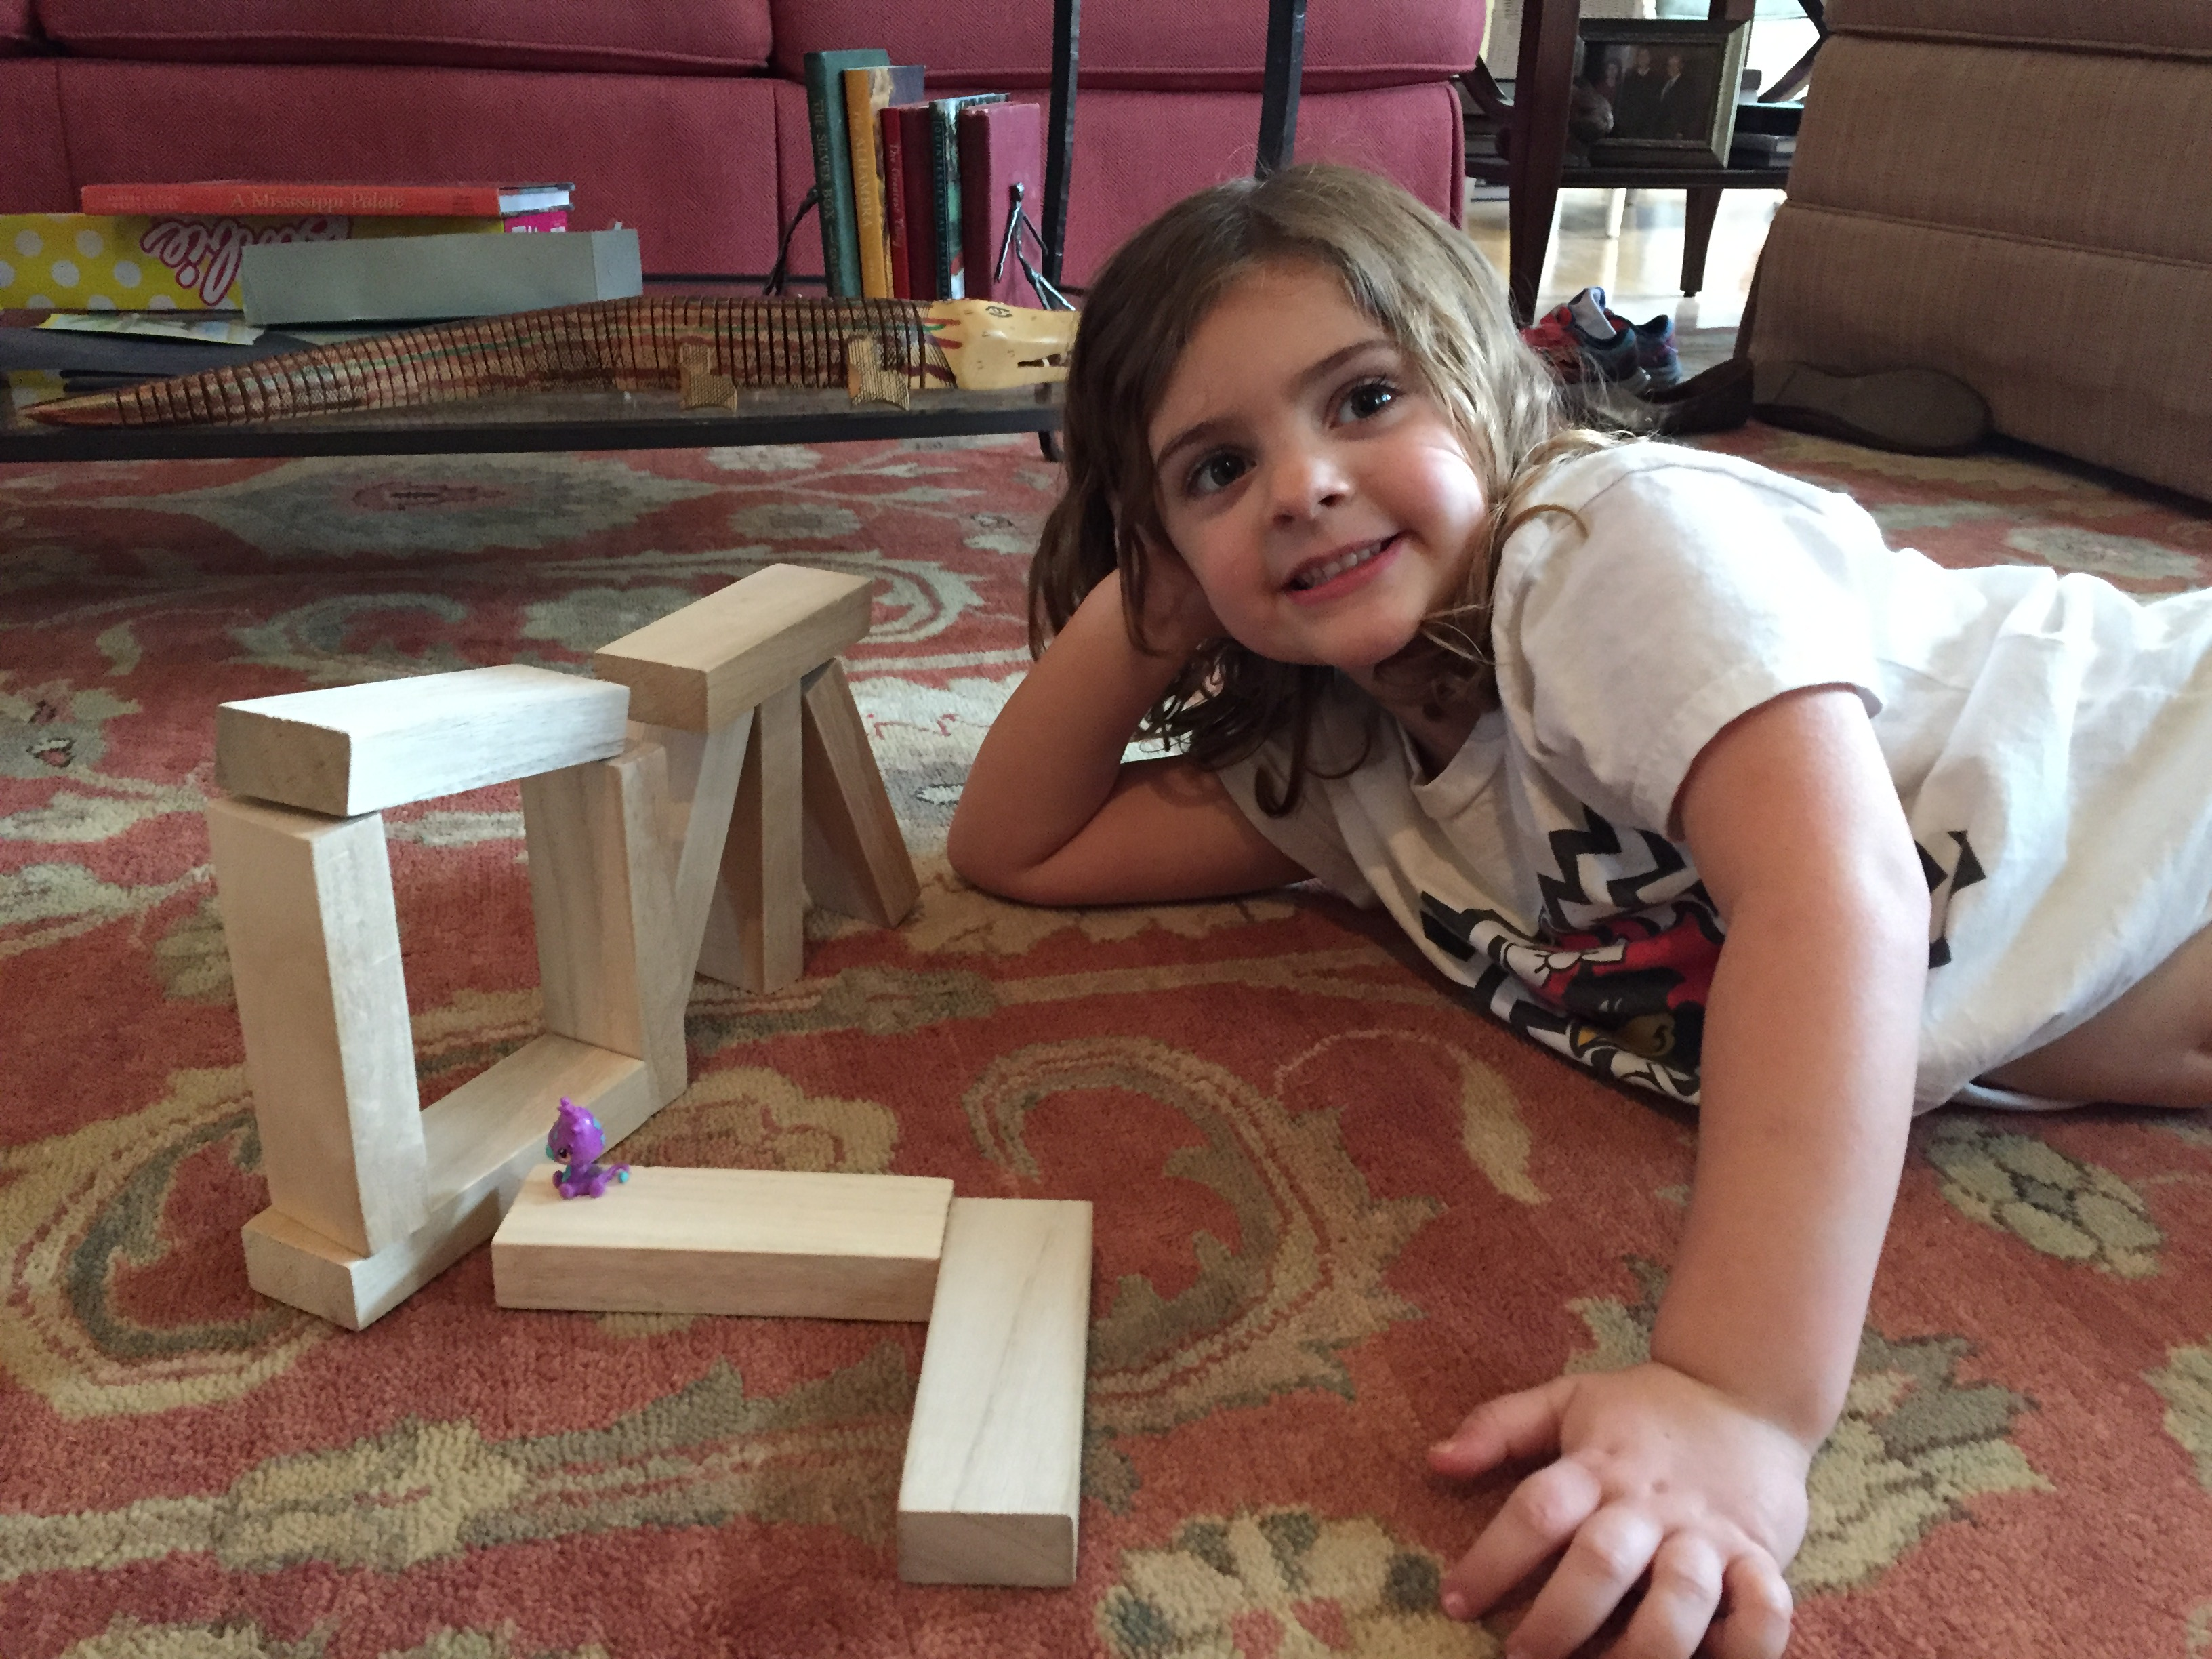

/mnt/4C74F47B74F468DA/Pictures/IMG_0033-2017-12-27 175948.JPG


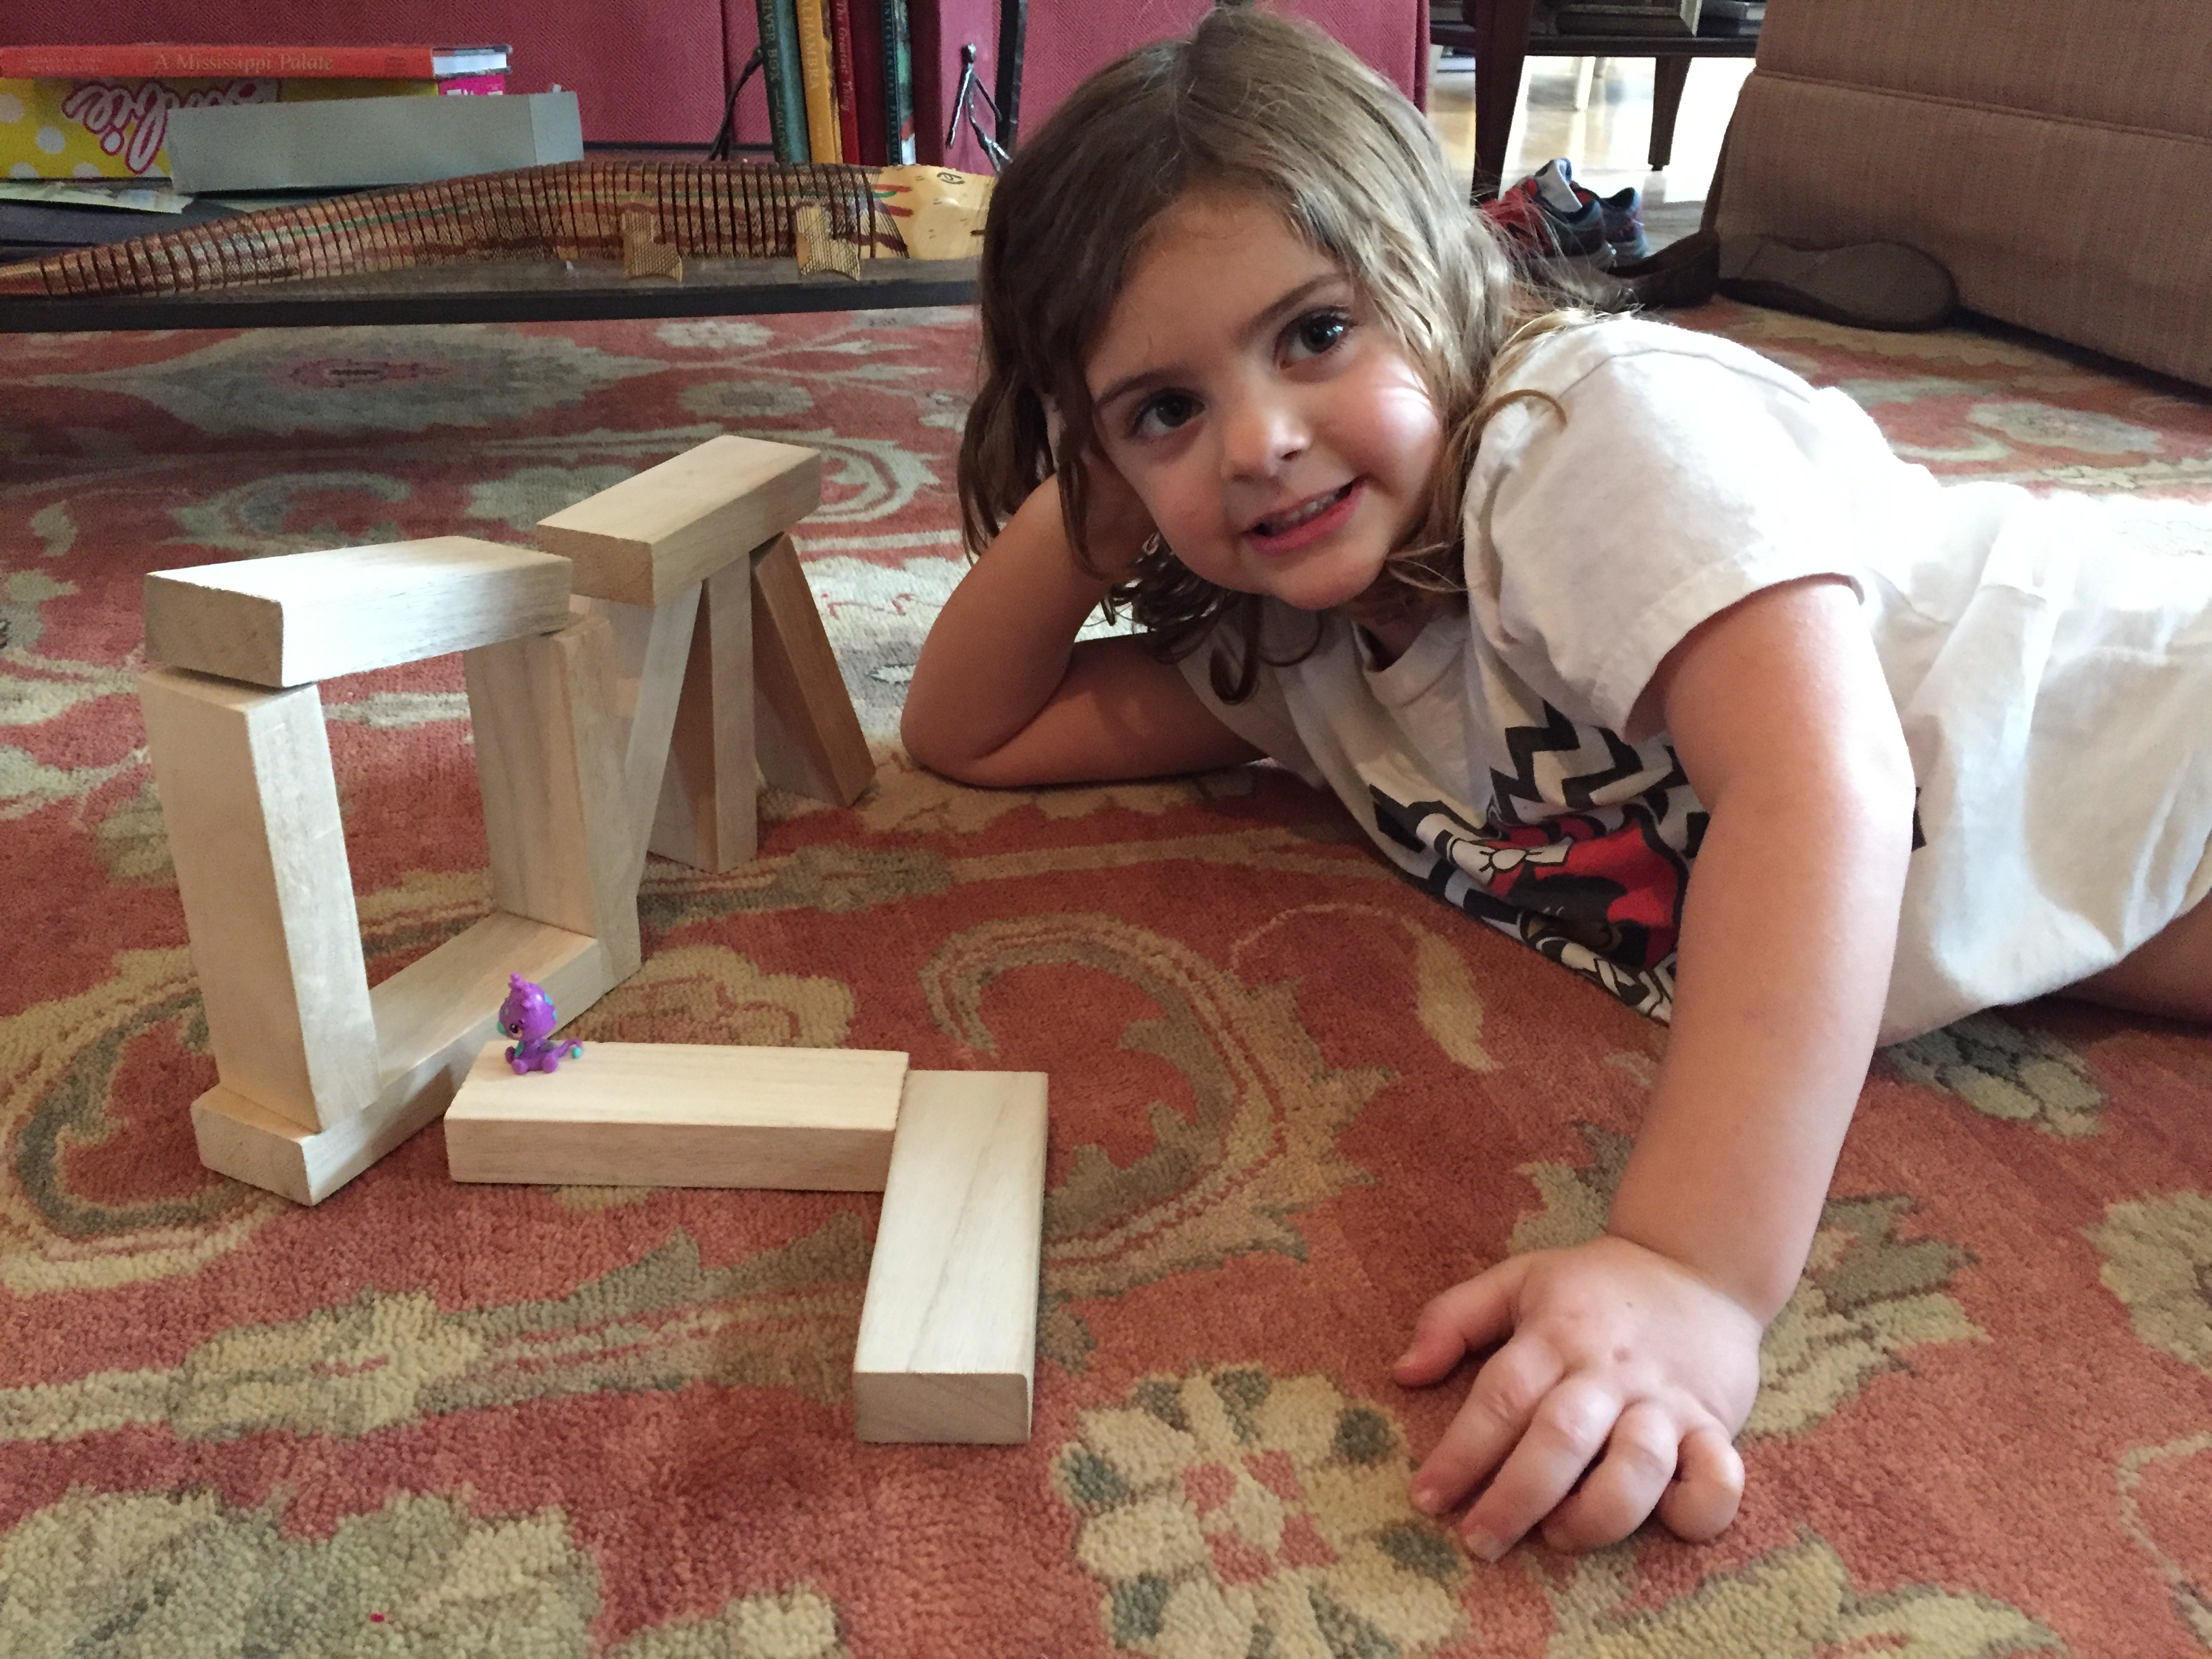

/mnt/4C74F47B74F468DA/Pictures/IMG_3251-2014-09-01 022828-2014-09-01 022828.JPG


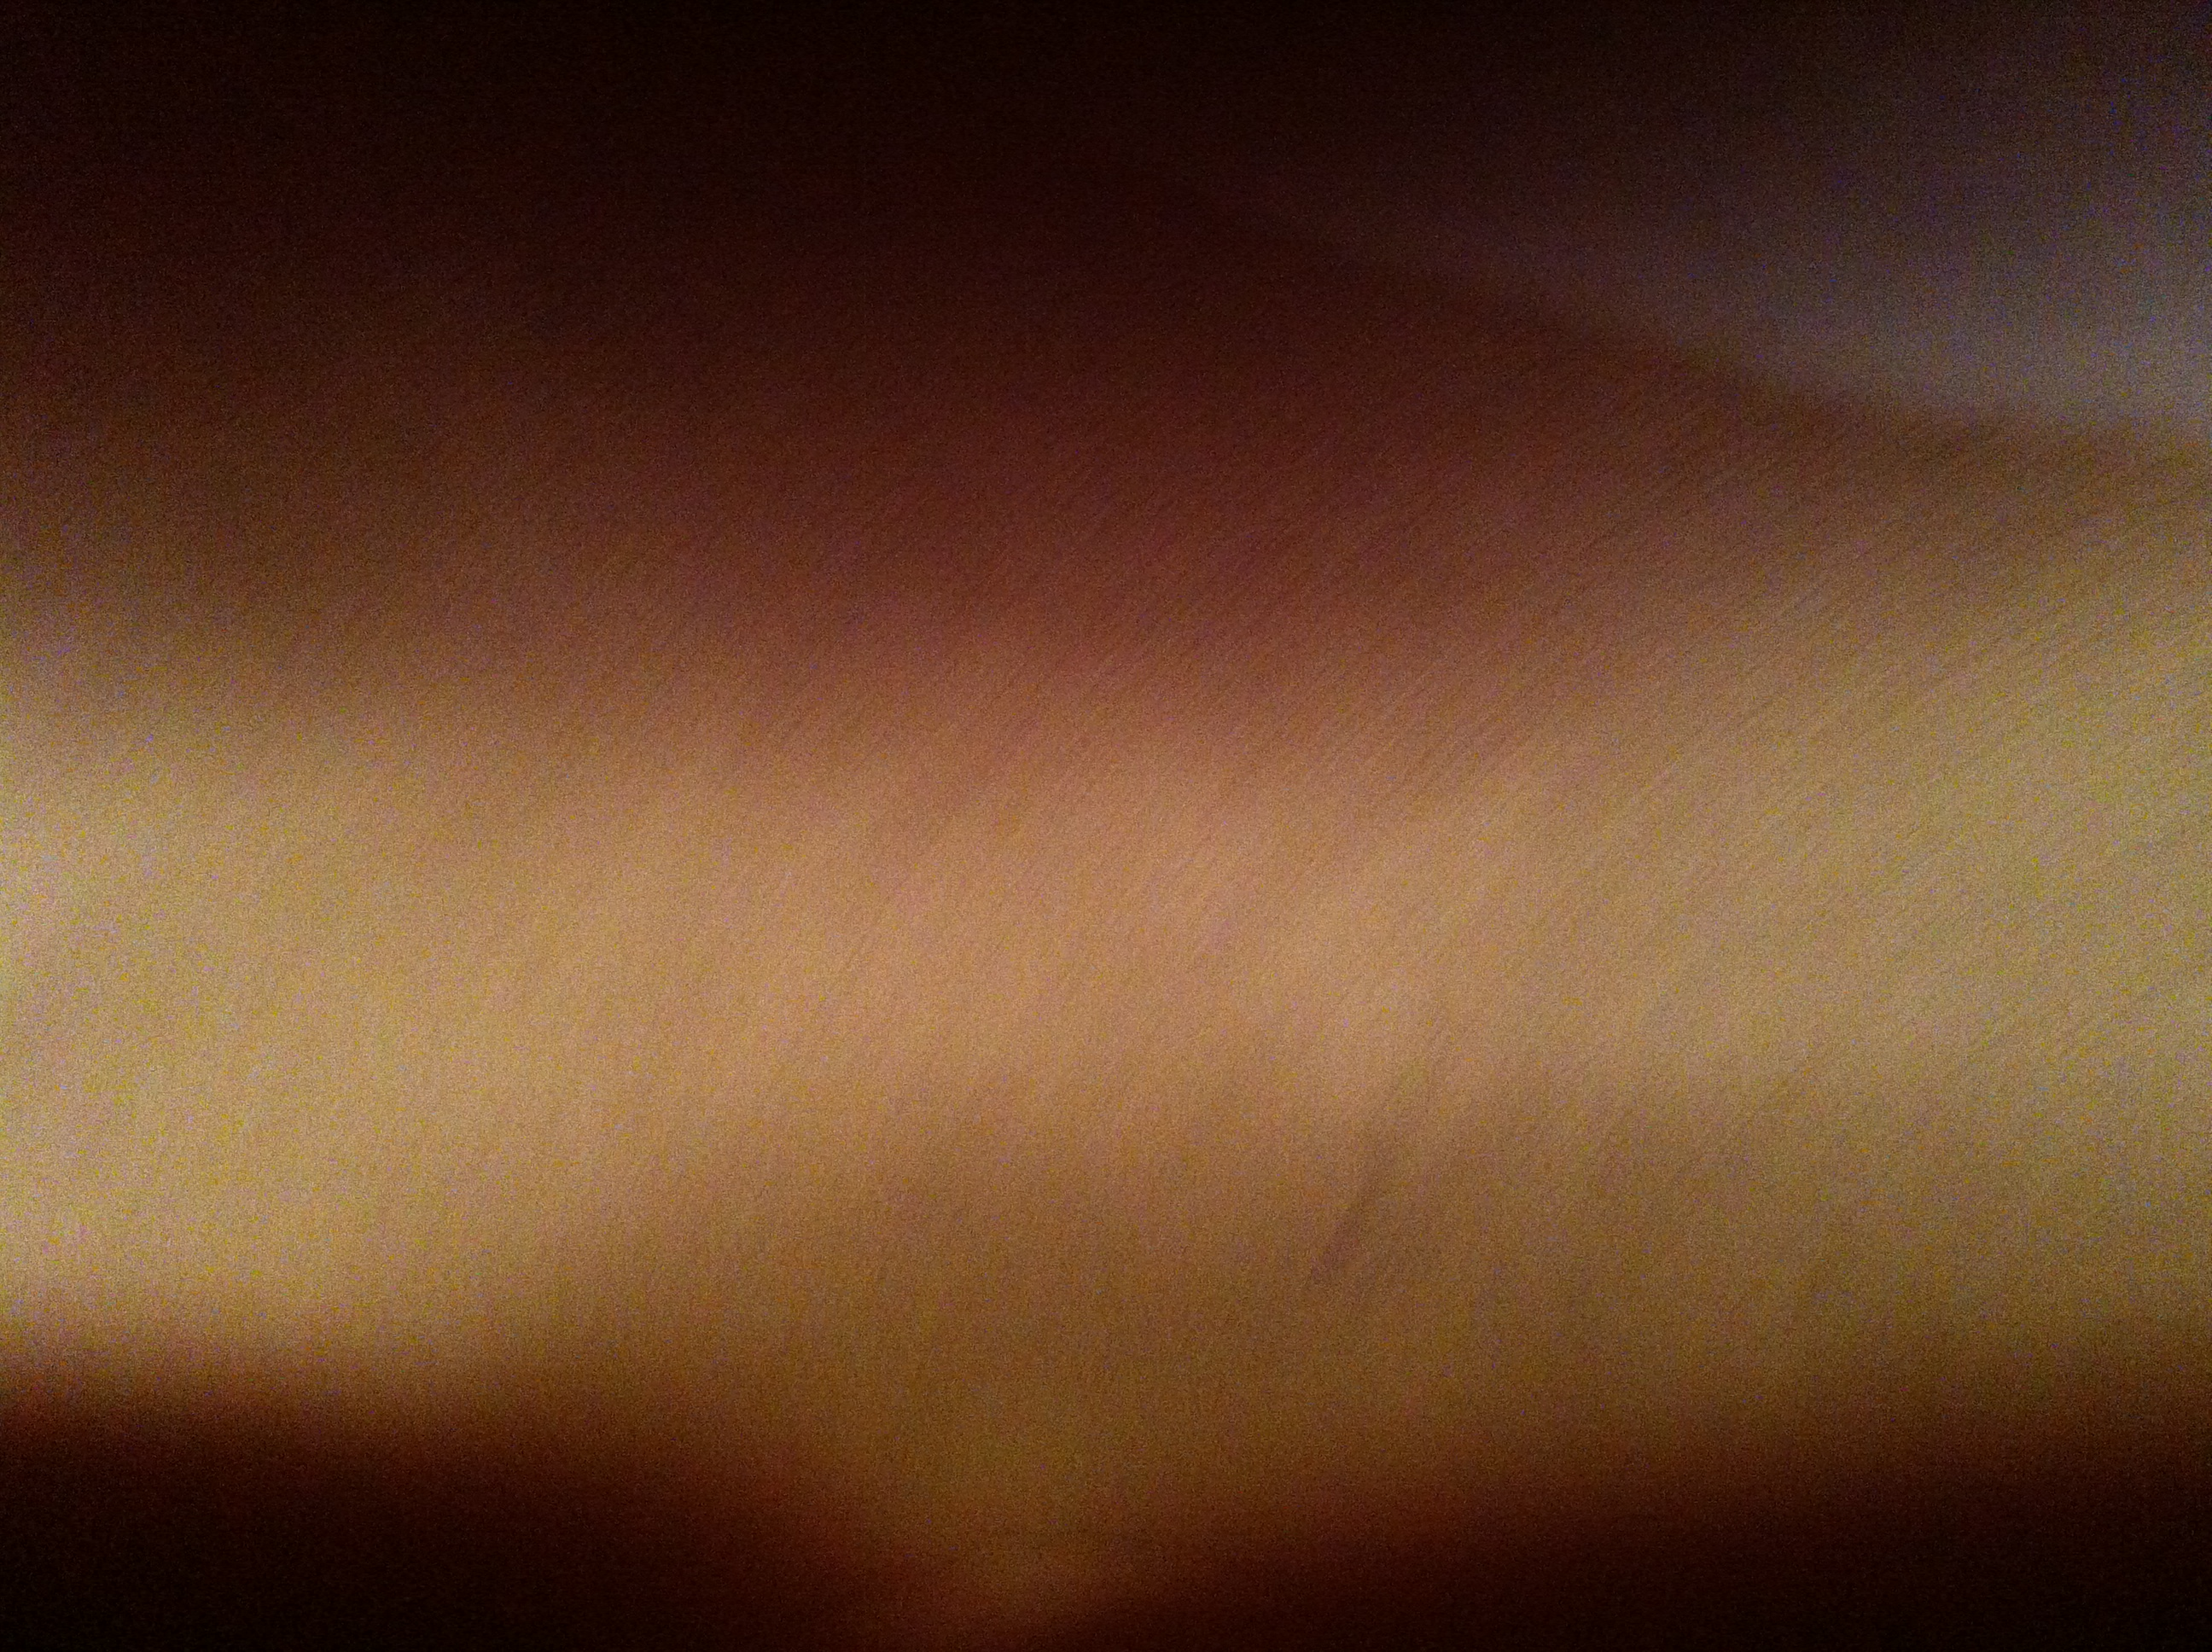

'/mnt/4C74F47B74F468DA/Pictures/IMG_0032-2017-12-27 175948.JPG'

In [16]:
from fx import show

imgs = [
    # '/mnt/4C74F47B74F468DA/Pictures/IMG_0822-2005-01-04 015604.JPG', # blurry finger
    # '/mnt/4C74F47B74F468DA/Pictures/IMG_0823-2005-01-04 015606.JPG', # blurry red nothing
    # 'labeled_pics/daughter.JPG',
    '/mnt/4C74F47B74F468DA/Pictures/IMG_0032-2017-12-27 175948.JPG',
    '/mnt/4C74F47B74F468DA/Pictures/IMG_0033-2017-12-27 175948.JPG',
    '/mnt/4C74F47B74F468DA/Pictures/IMG_3251-2014-09-01 022828-2014-09-01 022828.JPG',
    # '/mnt/4C74F47B74F468DA/Pictures/DSC_0267-2018-06-15 065130.JPG',
]

for p in imgs:
    print(p)
    show(p)

imgs[0]


In [13]:
h1 = phash(imgs[0])
h2 = phash(imgs[1])

dist = hamming_distance(h1, h2)

print("Hash 1:", ''.join(map(str, h1.astype(int))))
print("Hash 2:", ''.join(map(str, h2.astype(int))))
print("Hamming distance:", dist)

# Simple interpretation
if dist < 10:
    print("Images are very similar")
elif dist < 20:
    print("Images are somewhat similar")
else:
    print("Images are different")

Hash 1: 1010010000010010010111100110100110101001101011010001011100011111
Hash 2: 1010010000110010010110100101111001101001101011001110010110100101
Hamming distance: 20
Images are different


In [20]:
hamming_distance(phash(imgs[0]), phash(imgs[1]))
hamming_distance(phash(imgs[0]), phash(imgs[2]))

# doesn't seem very precise

20

26